In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from ReadParticle import read_particle_frames
from frame_renderer import init_worker, render_phase_angle_histogram

#filenames = ['particles1.txt']
filenames = ['particles_1mm.txt', 'particles_3mm.txt', 'particles_4mm.txt', 'particles_5mm.txt',
             'particles_7mm.txt', 'particles_1cm.txt', 'particles_5cm.txt', 'particles_10cm.txt']

datasets = []
# Read particle data
for file in filenames:
    
    Np_seq, time, r_dust, data_p = read_particle_frames(file)
    dataset = {}
    dataset['Np_seq'] = Np_seq
    dataset['time'] = time
    dataset['r_dust'] = r_dust
    dataset['data_p'] = data_p

    datasets.append(dataset)

num_datasets = len(datasets)

processing completed!
processing completed!
processing completed!
processing completed!
processing completed!
processing completed!
processing completed!
processing completed!


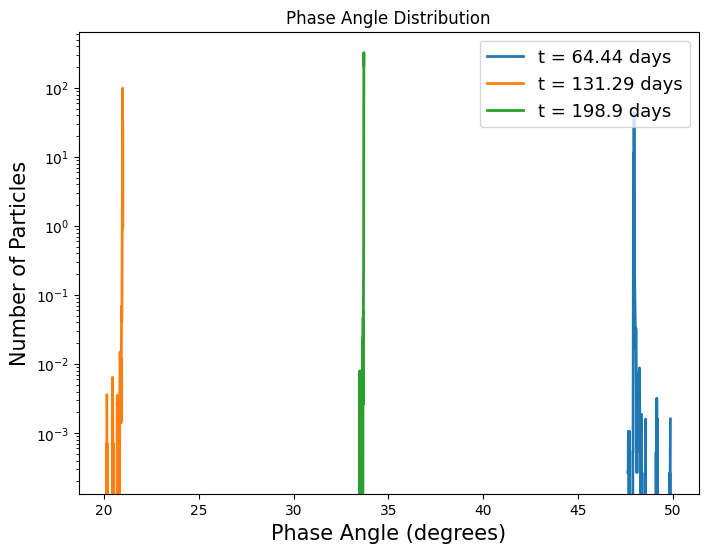

In [6]:
"""Phase angle of all-size particles"""
daylist = [64.44 ,131.29, 198.9]

fig, ax = plt.subplots(figsize=(8, 6))

for day in daylist:
    target_seconds = day*86400

    # combine datasets of all sizes
    pos_dust_allsize = []
    for i in range(num_datasets):
        # get the frame index at the time
        t_idx = np.searchsorted(datasets[i]['time'], target_seconds, side="left")
        
        # position vectors
        p_t = datasets[i]['data_p'][t_idx]
        pos_dust_allsize.append(p_t[4:,1:4])
        if i==3:  #either average the position of sun and earth across datasets, or interpolate position of dusts to a certain moment
            pos_sun = p_t[2,1:4]
            pos_earth = p_t[3,1:4]
    
    pos_dust_allsize = np.vstack(pos_dust_allsize)
    
    # Compute vectors
    vec_sun = pos_sun - pos_dust_allsize  # Vectors from Sun to dust particles
    vec_earth = pos_earth - pos_dust_allsize  # Vectors from Earth to dust particles
    
    # Compute norms
    norm_sun = np.linalg.norm(vec_sun, axis=1)  # Magnitudes of Sun vectors
    norm_earth = np.linalg.norm(vec_earth, axis=1)  # Magnitudes of Earth vectors
    
    # Compute dot products
    dot_product = np.einsum('ij,ij->i', vec_sun, vec_earth)  # Dot product of Sun and Earth vectors
    
    # Compute phase angles
    cos_phase_angle = dot_product / (norm_sun * norm_earth)  # Cosine of phase angle
    phase_angle = np.arccos(np.clip(cos_phase_angle, -1.0, 1.0))  # Phase angle in radians
    phase_angle_deg = np.degrees(phase_angle)
    
    # Compute histogram of phase angles
    counts, bin_edges = np.histogram(phase_angle_deg, bins=200, density=True)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    
    # plot distribution of phase angles
    ax.plot(bin_centers, counts, lw=2, label=f't = {day} days')
    #plt.bar(bin_centers, counts, width=bin_edges[1]-bin_edges[0])

ftsize = 15
ax.set_yscale('log')
ax.set_xlabel('Phase Angle (degrees)', fontsize=ftsize)
ax.set_ylabel('Number of Particles', fontsize=ftsize)
ax.set_title('Phase Angle Distribution')
ax.legend(fontsize=ftsize-2)

# Save the PNG image
figname = "phase_angle_allsize.png"
plt.savefig(figname, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

2023-02-05 06:14:40.183000


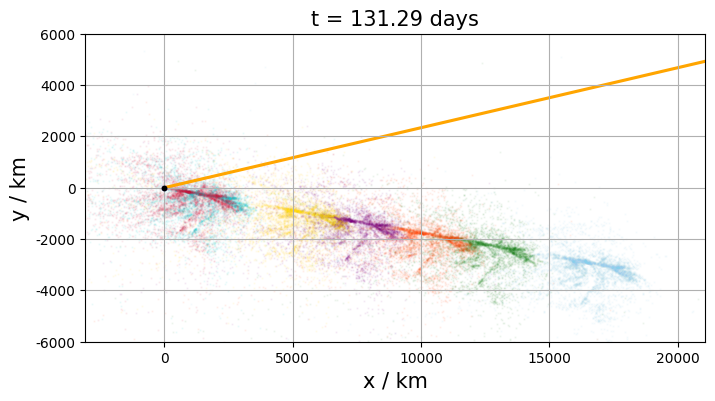

In [3]:
"""HST view of particles in all sizes"""
import os
from datetime import datetime, timedelta
import importlib
import frame_renderer
importlib.reload(frame_renderer)
from frame_renderer import init_worker, render_single_HSTview_colorgroups

# Ensure output directory exists for saving frames
output_dir = "allsize_HSTview"
os.makedirs(output_dir, exist_ok=True)

# parameters
# daylist = [64.44]                                 # set the day to plot
# axis_lims = [-1000e3, 5000e3, -2000e3, 4000e3]    # m
daylist = [131.29]                                 # set the day to plot
axis_lims = [-2000e3, 20000e3, -6000e3, 6000e3]    # m
# daylist = [198.9]                               # set the day to plot
# axis_lims = [-2000e3, 35000e3, -5000e3, 10000e3]    # m

#axis_lims = 20000e3
sid = 4                                            # starting index of dusts (0-3 are Didymos, Dimorphos, Sun, Earth)
size_weight = [0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125]
alpha = 0.05                                  # transparency of the plotted points                
group_labels = {1: ['1 mm', '#8B4513'],
                2: ['3 mm', '#87CEEB'],
                3: ['4 mm', '#228B22'],
                4: ['5 mm', '#FF4500'],
                5: ['7 mm', '#800080'],  # Purple
                6: ['1 cm', '#FFD700'],  # Gold (Yellow)
                7: ['5 cm', '#00CED1'],
                8: ['10 cm', '#DC143C']
               }

# print datetime
start_time = datetime.strptime("2022-09-26 23:17:04.1830", "%Y-%m-%d %H:%M:%S.%f")
new_time = start_time + timedelta(days=daylist[0])
print(new_time)

# check if parameters are correctly set
assert num_datasets==len(size_weight), f"{num_datasets} datasets are given, but the weights of {len(size_weight)} of them are set."

for day in daylist:
    target_seconds = day*86400

    # combine datasets of all sizes
    p_allsize = []
    for i in range(num_datasets):
        # get the frame index at the time
        t_idx = np.searchsorted(datasets[i]['time'], target_seconds, side="left")

        # get the particle data at the time
        p_t = datasets[i]['data_p'][t_idx]

        # add a new column denoting the group of particles
        new_col = np.full((p_t.shape[0], 1), i+1)
        new_col[:sid] = 0  # Didymos, Dimorphos, Sun, Earth should not be grouped with other particles
        p_t = np.hstack((p_t, new_col))
        
        # randomly select dusts based on weight percentage and add dust data to the list
        num_select = int(size_weight[i] * (len(p_t) - sid))
        selected_indices = np.random.choice(range(sid,len(p_t)-1), num_select, replace=False)
        p_allsize.append(p_t[selected_indices])

        # add Didymos, Dimorphos, Sun, Earth to the beginning of the list
        if i==0:  #either average the position of sun and earth across datasets, or interpolate position of dusts to a certain moment
            p_allsize.insert(0, p_t[:sid])
    
    p_allsize = np.vstack(p_allsize)

    # pass global variables
    init_worker(data_p=[p_allsize], time=np.array([target_seconds]), axis_lim_list=axis_lims, output_dir=output_dir, group_labels=group_labels)
    # make plot for single frame
    render_single_HSTview_colorgroups(0, alpha=alpha)

In [2]:
"""plot main body locations in Sun Body Center"""

import os
from multiprocessing import Pool
import numpy as np
from frame_renderer import init_worker, render_location_sun_center, test238pm

# Ensure output directory exists for saving frames
output_dir = "mainbody_location_frames"
if os.path.exists(output_dir):
    import shutil
    shutil.rmtree(output_dir)
os.makedirs(output_dir, exist_ok=True)

# Parameters
num_frames = len(datasets[0]['time'])
fps = 24
axis_lim = 3 * 1.49e11   # m
output_name = "mainbody_locations.mp4"

if __name__ == "__main__": 
    # Render all frames in parallel
    with Pool(initializer=init_worker, initargs=(datasets[0]['data_p'], datasets[0]['time'], axis_lim, output_dir)) as pool:
        pool.map(render_location_sun_center, range(num_frames))
    print("All frames rendered. Combining into video...")

    # Combine frames into an MP4 using ffmpeg
    os.system(f"ffmpeg -y -r {fps} -i {output_dir}/frame_%04d.png -vf 'pad=ceil(iw/2)*2:ceil(ih/2)*2' -vcodec libx264 -crf 18 -pix_fmt yuv420p {output_name}")

    print(f"Animation saved as {output_name}",flush=True)

All frames rendered. Combining into video...ering frame 8...Rendering frame 4...Rendering frame 10...Rendering frame 6...Rendering frame 12...Rendering frame 16...Rendering frame 14...Rendering frame 18...Rendering frame 20...Rendering frame 22...Rendering frame 24...Rendering frame 26...Rendering frame 30...Rendering frame 32...Rendering frame 46...Rendering frame 48...Rendering frame 50...Rendering frame 54...Rendering frame 56...Rendering frame 52...Rendering frame 62...Rendering frame 68...Rendering frame 64...Rendering frame 70...Rendering frame 66...Rendering frame 72...Rendering frame 78...Rendering frame 80...Rendering frame 88...Rendering frame 90...Rendering frame 86...Rendering frame 94...Rendering frame 98...Rendering frame 104...Rendering frame 108...Rendering frame 100...Rendering frame 74...Rendering frame 102...Rendering frame 110...Rendering frame 112...Rendering frame 34...Rendering frame 38...Rendering frame 84...Rendering frame 44...Rendering frame 96...Rendering fr

ffmpeg version 4.2.9 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 8 (GCC)
  configuration: --prefix=/usr --bindir=/usr/bin --datadir=/usr/share/ffmpeg --docdir=/usr/share/doc/ffmpeg --incdir=/usr/include/ffmpeg --libdir=/usr/lib64 --mandir=/usr/share/man --arch=x86_64 --optflags='-O2 -g -pipe -Wall -Werror=format-security -Wp,-D_FORTIFY_SOURCE=2 -Wp,-D_GLIBCXX_ASSERTIONS -fexceptions -fstack-protector-strong -grecord-gcc-switches -specs=/usr/lib/rpm/redhat/redhat-hardened-cc1 -specs=/usr/lib/rpm/redhat/redhat-annobin-cc1 -m64 -mtune=generic -fasynchronous-unwind-tables -fstack-clash-protection -fcf-protection' --extra-ldflags='-Wl,-z,relro -Wl,-z,now -specs=/usr/lib/rpm/redhat/redhat-hardened-ld ' --extra-cflags=' ' --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libvo-amrwbenc --enable-version3 --enable-bzlib --disable-crystalhd --enable-fontconfig --enable-frei0r --enable-gcrypt --enable-gnutls --enable-ladspa --enable-libaom --enable-libdav1d --enabl

Animation saved as dimor_locations.mp4


frame=  300 fps= 67 q=-1.0 Lsize=     204kB time=00:00:12.37 bitrate= 135.3kbits/s speed=2.77x    
video:200kB audio:0kB subtitle:0kB other streams:0kB global headers:0kB muxing overhead: 2.172385%
[libx264 @ 0x561a91096e00] frame I:2     Avg QP: 4.69  size: 36422
[libx264 @ 0x561a91096e00] frame P:76    Avg QP:21.01  size:   833
[libx264 @ 0x561a91096e00] frame B:222   Avg QP:17.34  size:   306
[libx264 @ 0x561a91096e00] consecutive B-frames:  1.3%  0.0%  0.0% 98.7%
[libx264 @ 0x561a91096e00] mb I  I16..4: 88.7%  7.4%  4.0%
[libx264 @ 0x561a91096e00] mb P  I16..4:  0.0%  0.0%  0.0%  P16..4:  0.6%  0.0%  0.0%  0.0%  0.0%    skip:99.3%
[libx264 @ 0x561a91096e00] mb B  I16..4:  0.0%  0.0%  0.0%  B16..8:  0.2%  0.0%  0.0%  direct: 0.0%  skip:99.7%  L0:53.3% L1:45.9% BI: 0.8%
[libx264 @ 0x561a91096e00] 8x8 transform intra:10.0% inter:10.1%
[libx264 @ 0x561a91096e00] coded y,uvDC,uvAC intra: 3.4% 0.1% 0.1% inter: 0.0% 0.0% 0.0%
[libx264 @ 0x561a91096e00] i16 v,h,dc,p: 90%  9%  1%  0%
[libx2